In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look cleaner
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv('../data/kenya_clinic_wait_times.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

Shape: (5000, 11)

Column types:
date                  object
hour                   int64
day_of_week            int64
day_name              object
month                  int64
hospital              object
county                object
department            object
wait_time_mins         int64
satisfaction_score     int64
is_weekend             int64
dtype: object

First 5 rows:


,date,hour,day_of_week,day_name,month,hospital,county,department,wait_time_mins,satisfaction_score,is_weekend
0,2024-10-16,8,2,Wednesday,10,Mama Lucy Kibaki Hospital,Nairobi,Maternity,82,2,0
1,2023-05-23,14,1,Tuesday,5,Coast General Hospital,Mombasa,Outpatient,115,4,0
2,2024-03-08,7,4,Friday,3,Kenyatta National Hospital,Nairobi,Maternity,55,3,0
3,2024-06-01,12,5,Saturday,6,Coast General Hospital,Mombasa,Maternity,47,5,1
4,2024-10-27,13,6,Sunday,10,Moi Teaching & Referral Hospital,Eldoret,Maternity,18,5,1


In [3]:
print("WAIT TIME STATISTICS (minutes)")
print("-"*35)
print(f"Average wait:   {df['wait_time_mins'].mean():.1f} mins")
print(f"Median wait:    {df['wait_time_mins'].median():.1f} mins")
print(f"Shortest wait:  {df['wait_time_mins'].min()} mins")
print(f"Longest wait:   {df['wait_time_mins'].max()} mins")
print(f"Std deviation:  {df['wait_time_mins'].std():.1f} mins")

WAIT TIME STATISTICS (minutes)
-----------------------------------
Average wait:   87.3 mins
Median wait:    68.0 mins
Shortest wait:  5 mins
Longest wait:   300 mins
Std deviation:  68.3 mins


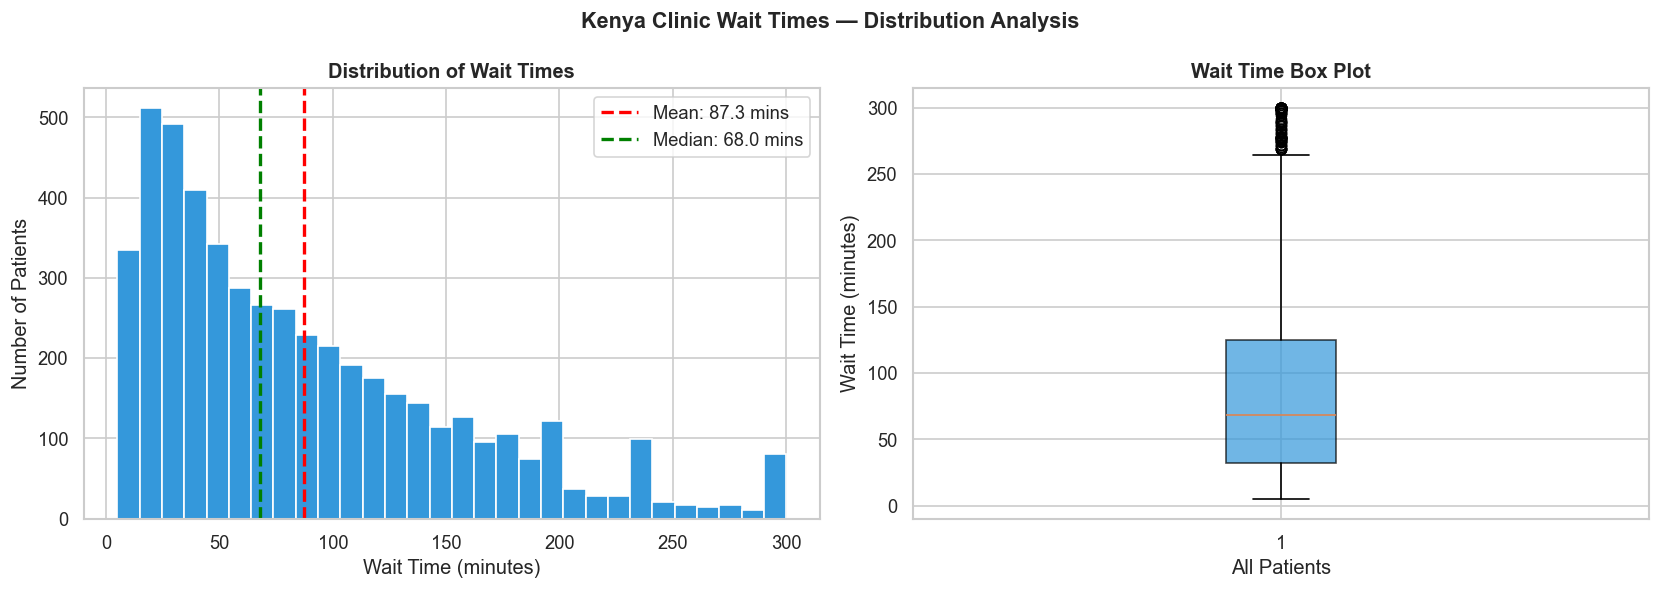

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — histogram
axes[0].hist(df['wait_time_mins'], 
             bins=30, 
             color='#3498db', 
             edgecolor='white')
axes[0].axvline(df['wait_time_mins'].mean(), 
                color='red', 
                linestyle='--', 
                linewidth=2,
                label=f"Mean: {df['wait_time_mins'].mean():.1f} mins")
axes[0].axvline(df['wait_time_mins'].median(), 
                color='green', 
                linestyle='--', 
                linewidth=2,
                label=f"Median: {df['wait_time_mins'].median():.1f} mins")
axes[0].set_title('Distribution of Wait Times', fontweight='bold')
axes[0].set_xlabel('Wait Time (minutes)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# Right chart — box plot
axes[1].boxplot(df['wait_time_mins'], 
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Wait Time Box Plot', fontweight='bold')
axes[1].set_ylabel('Wait Time (minutes)')
axes[1].set_xlabel('All Patients')

plt.suptitle('Kenya Clinic Wait Times — Distribution Analysis', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/wait_time_distribution.png', dpi=150)
plt.show()

In [5]:
# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Average wait time per day
daily_avg = df.groupby('day_name')['wait_time_mins'].agg(['mean', 'median', 'count'])
daily_avg = daily_avg.reindex(day_order)
daily_avg.columns = ['avg_wait', 'median_wait', 'patient_count']

print(daily_avg.round(1))

           avg_wait  median_wait  patient_count
day_name                                       
Monday        144.9        136.0            711
Tuesday       105.5         94.0            719
Wednesday      77.6         69.0            715
Thursday       91.8         82.0            732
Friday        121.5        110.0            697
Saturday       46.5         39.0            716
Sunday         23.8         20.0            710


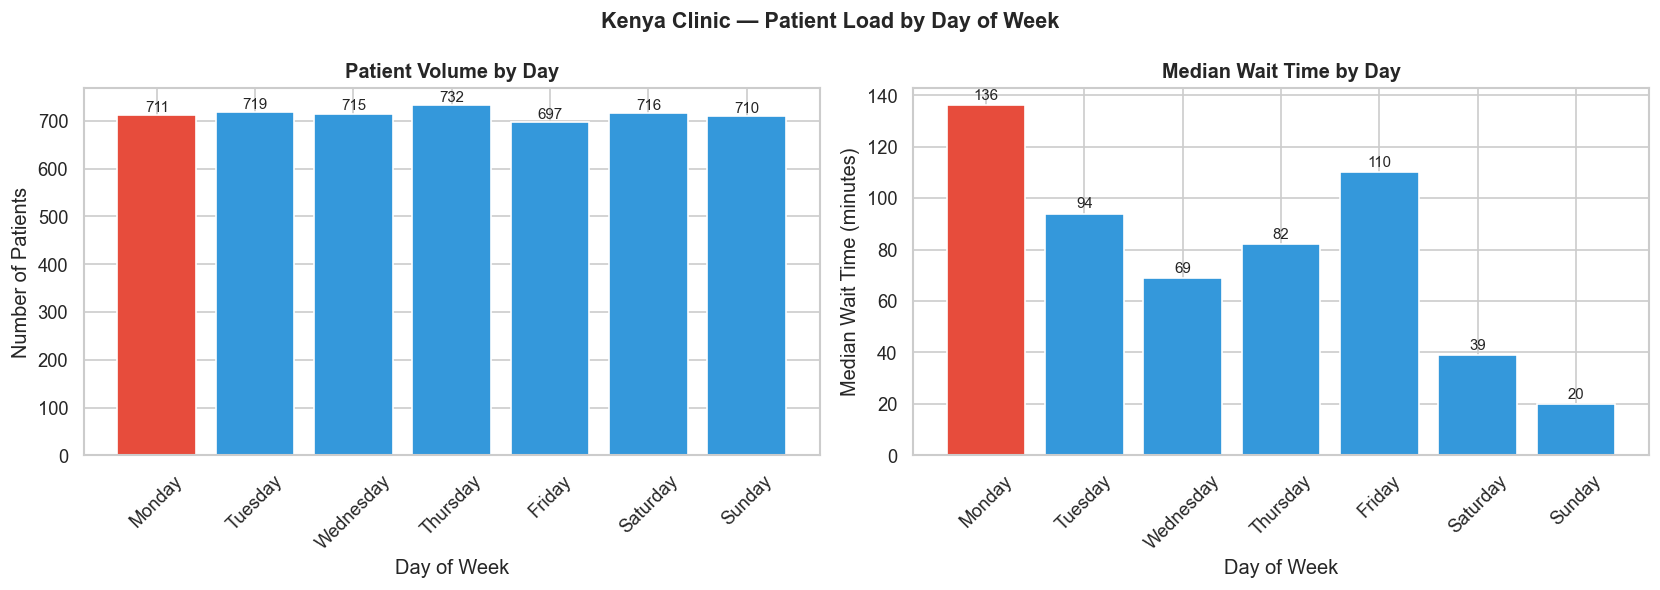

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — patient count per day
colors = ['#e74c3c' if day == 'Monday' else '#3498db' for day in daily_avg.index]

axes[0].bar(daily_avg.index, 
            daily_avg['patient_count'],
            color=colors,
            edgecolor='white')
axes[0].set_title('Patient Volume by Day', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

# Right — median wait time per day
axes[1].bar(daily_avg.index,
            daily_avg['median_wait'],
            color=colors,
            edgecolor='white')
axes[1].set_title('Median Wait Time by Day', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Median Wait Time (minutes)')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{bar.get_height():.0f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Kenya Clinic — Patient Load by Day of Week',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/daily_patterns.png', dpi=150)
plt.show()

In [7]:
# Calculate department statistics first
dept_stats = df.groupby('department')['wait_time_mins'].agg(['mean', 'median', 'count'])
dept_stats = dept_stats.sort_values('median', ascending=False)
print(dept_stats.round(1))

                     mean  median  count
department                              
General Surgery     136.0   120.0   1005
Outpatient          104.3    94.0    994
Pediatrics           88.2    79.0   1034
Maternity            65.9    55.0   1007
Casualty/Emergency   40.2    35.0    960


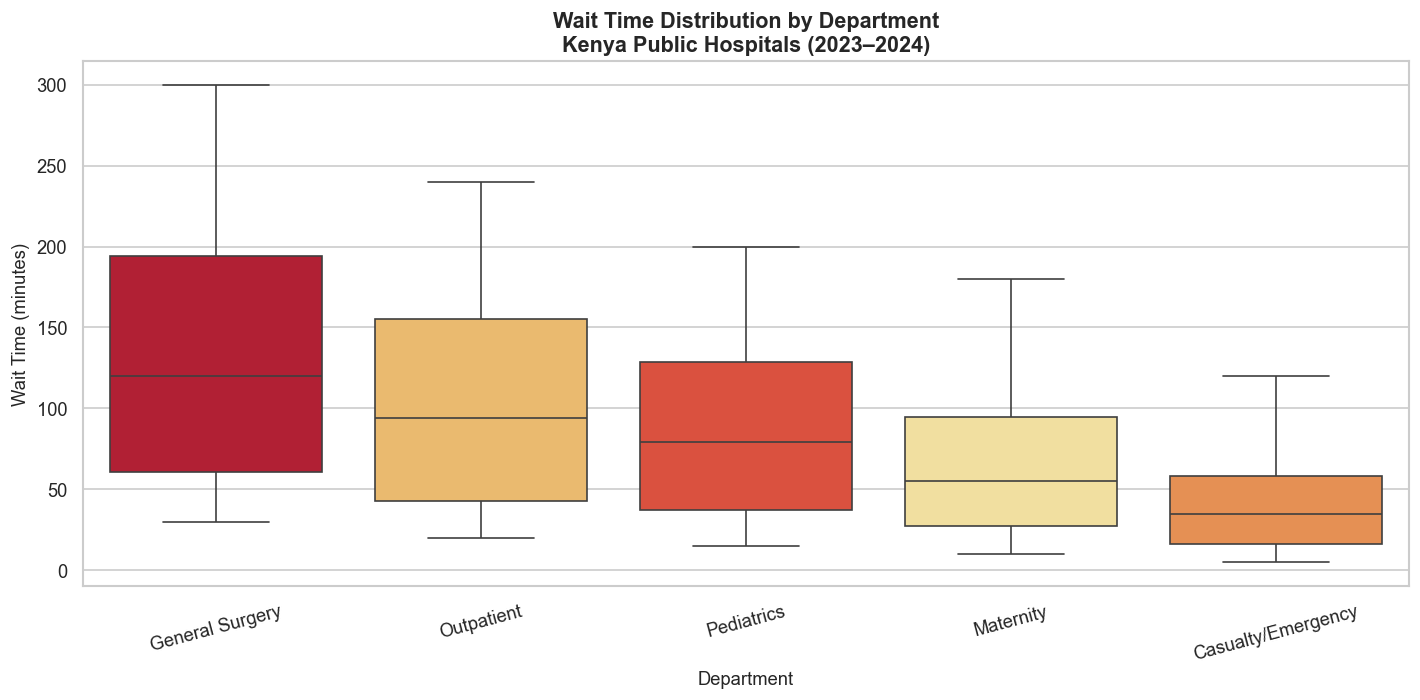

In [19]:
# Sort departments by median wait time
dept_order = df.groupby('department')['wait_time_mins'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))

sns.boxplot(data=df,
            x='department',
            y='wait_time_mins',
            order=dept_order,
            hue='department',
            legend=False,
            palette='YlOrRd')

plt.title('Wait Time Distribution by Department\nKenya Public Hospitals (2023–2024)',
          fontsize=13, fontweight='bold')
plt.xlabel('Department', fontsize=11)
plt.ylabel('Wait Time (minutes)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/department_boxplot.png', dpi=150)
plt.show()

In [9]:
# Create a pivot table — days as rows, hours as columns, avg wait as values
heatmap_data = df.pivot_table(
    values='wait_time_mins',
    index='day_name',
    columns='hour',
    aggfunc='median'
)

# Reorder days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

print(heatmap_data.round(0))

hour         6     7      8      9      10     11     12     13     14     15  \
day_name                                                                        
Monday     20.0  70.0  180.0  180.0  190.0  169.0  128.0  148.0  136.0  119.0   
Tuesday    21.0  46.0  116.0  154.0  142.0   97.0   86.0   97.0  106.0   80.0   
Wednesday  14.0  34.0   80.0  110.0   93.0   76.0   69.0   79.0   66.0   53.0   
Thursday   21.0  37.0  106.0  132.0  116.0  105.0   71.0   92.0   84.0   69.0   
Friday     28.0  56.0  137.0  176.0  154.0  120.0  114.0  122.0  112.0   85.0   
Saturday   18.0  16.0   52.0   63.0   54.0   46.0   34.0   49.0   44.0   30.0   
Sunday     10.0  15.0   30.0   30.0   26.0   20.0   20.0   24.0   26.0   20.0   

hour         16    17    18    19  
day_name                           
Monday     85.0  56.0  34.0  25.0  
Tuesday    58.0  42.0  19.0  23.0  
Wednesday  45.0  30.0  15.0  11.0  
Thursday   56.0  34.0  20.0  18.0  
Friday     58.0  46.0  30.0  18.0  
Saturday   30.0  2

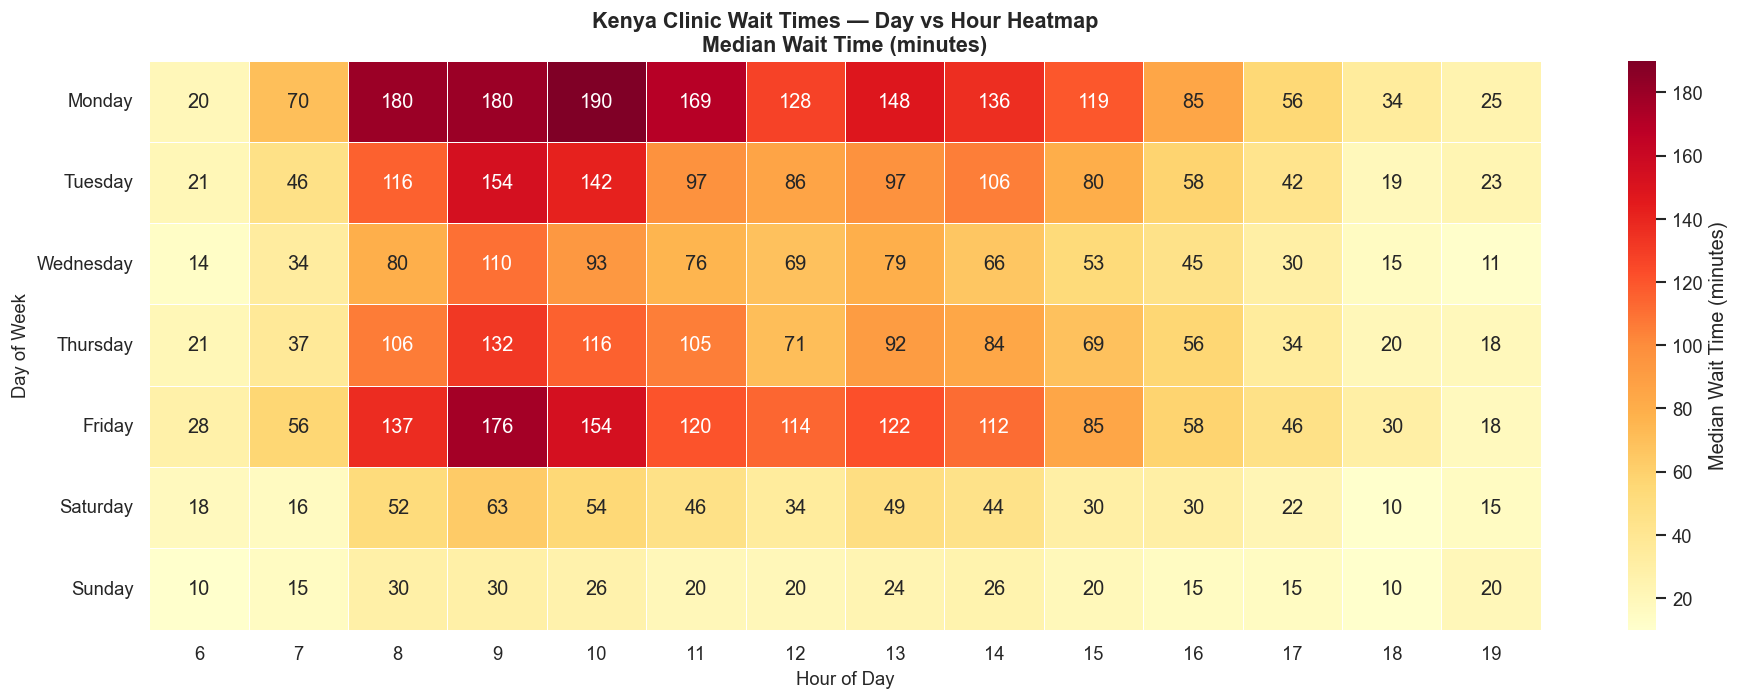

In [10]:
plt.figure(figsize=(16, 6))

sns.heatmap(heatmap_data,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Median Wait Time (minutes)'})

plt.title('Kenya Clinic Wait Times — Day vs Hour Heatmap\nMedian Wait Time (minutes)',
          fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=11)
plt.ylabel('Day of Week', fontsize=11)
plt.tight_layout()
plt.savefig('../data/wait_time_heatmap.png', dpi=150)
plt.show()

In [11]:
# Average wait time per hospital
hospital_stats = df.groupby('hospital')['wait_time_mins'].agg(['mean', 'median', 'count'])
hospital_stats = hospital_stats.sort_values('median', ascending=False)
hospital_stats.columns = ['avg_wait', 'median_wait', 'patient_count']

print(hospital_stats.round(1))

                                  avg_wait  median_wait  patient_count
hospital                                                              
Mama Lucy Kibaki Hospital             90.0         71.0           1026
Coast General Hospital                88.8         70.0            988
Moi Teaching & Referral Hospital      87.9         68.5           1010
Pumwani Maternity Hospital            85.9         67.0            972
Kenyatta National Hospital            83.7         64.0           1004


In [12]:
# Average satisfaction score per wait time bracket
df['wait_bracket'] = pd.cut(df['wait_time_mins'],
                             bins=[0, 30, 60, 90, 120, 300],
                             labels=['0-30', '31-60', '61-90', '91-120', '120+'])

satisfaction = df.groupby('wait_bracket', observed=True)['satisfaction_score'].mean()
print(satisfaction.round(2))

wait_bracket
0-30      4.46
31-60     3.94
61-90     3.05
91-120    2.88
120+      2.00
Name: satisfaction_score, dtype: float64


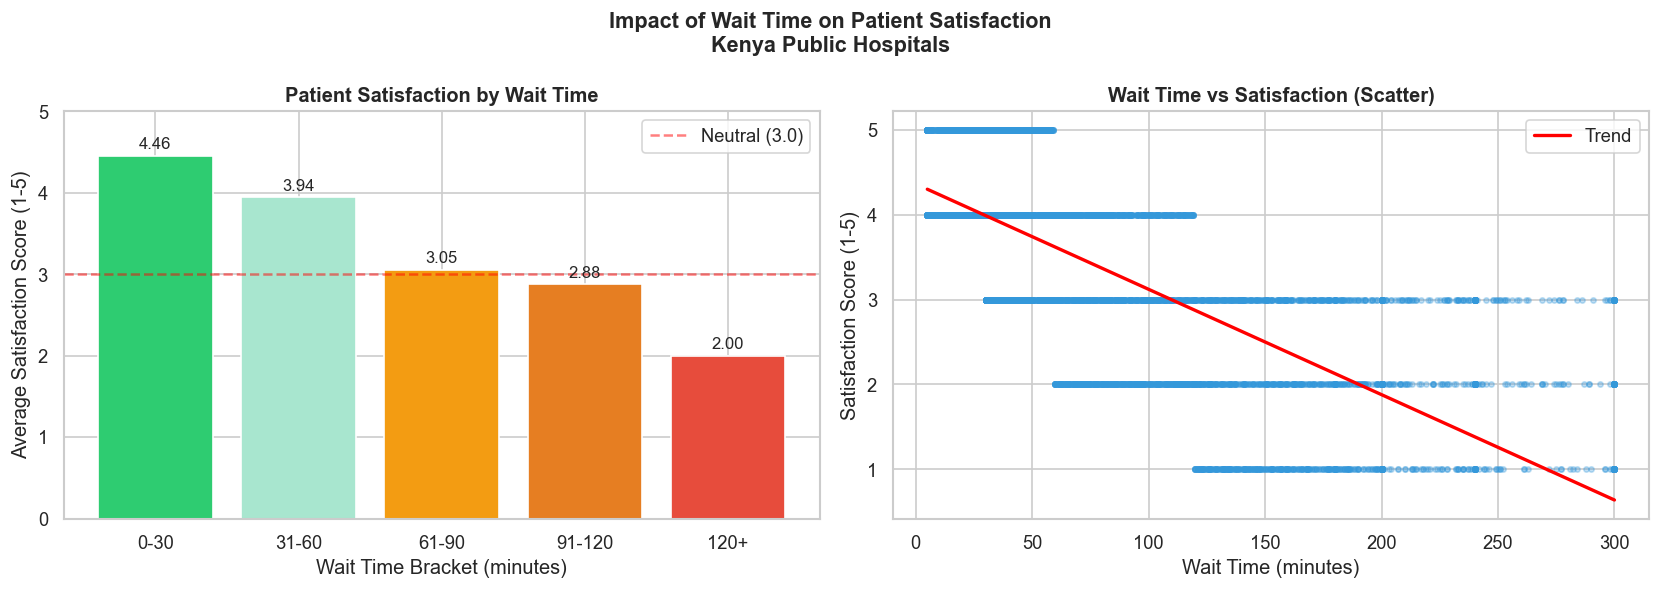

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — satisfaction by wait bracket
satisfaction_df = satisfaction.reset_index()
colors = ['#2ecc71', '#a8e6cf', '#f39c12', '#e67e22', '#e74c3c']

axes[0].bar(satisfaction_df['wait_bracket'],
            satisfaction_df['satisfaction_score'],
            color=colors,
            edgecolor='white')
axes[0].set_title('Patient Satisfaction by Wait Time', fontweight='bold')
axes[0].set_xlabel('Wait Time Bracket (minutes)')
axes[0].set_ylabel('Average Satisfaction Score (1-5)')
axes[0].set_ylim(0, 5)
axes[0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Neutral (3.0)')
axes[0].legend()

for bar, score in zip(axes[0].patches, satisfaction_df['satisfaction_score']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{score:.2f}',
                 ha='center', va='bottom', fontsize=10)

# Right — scatter plot of wait time vs satisfaction
axes[1].scatter(df['wait_time_mins'],
                df['satisfaction_score'],
                alpha=0.3,
                color='#3498db',
                s=10)

# Add trend line
z = np.polyfit(df['wait_time_mins'], df['satisfaction_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['wait_time_mins'].min(), df['wait_time_mins'].max(), 100)
axes[1].plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
axes[1].set_title('Wait Time vs Satisfaction (Scatter)', fontweight='bold')
axes[1].set_xlabel('Wait Time (minutes)')
axes[1].set_ylabel('Satisfaction Score (1-5)')
axes[1].legend()

plt.suptitle('Impact of Wait Time on Patient Satisfaction\nKenya Public Hospitals',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/satisfaction_analysis.png', dpi=150)
plt.show()

In [21]:
print("=" * 55)
print("KENYA CLINIC WAIT TIME ANALYSIS — KEY FINDINGS")
print("=" * 55)

busiest_day = daily_avg['patient_count'].idxmax()
quietest_day = daily_avg['patient_count'].idxmin()
worst_dept = dept_stats['median'].idxmax()
best_dept = dept_stats['median'].idxmin()
worst_hospital = hospital_stats['median_wait'].idxmax()
best_hospital = hospital_stats['median_wait'].idxmin()

print(f"""
DATASET
-------
Records:        {len(df):,}
Hospitals:      {df['hospital'].nunique()}
Departments:    {df['department'].nunique()}
Period:         2023 – 2024

WAIT TIME OVERVIEW
------------------
Average wait:   {df['wait_time_mins'].mean():.1f} mins
Median wait:    {df['wait_time_mins'].median():.1f} mins
Shortest wait:  {df['wait_time_mins'].min()} mins
Longest wait:   {df['wait_time_mins'].max()} mins


DAY INSIGHTS
------------
Busiest day:    {busiest_day} ({daily_avg['patient_count'].max():.0f} patients)
Quietest day:   {quietest_day} ({daily_avg['patient_count'].min():.0f} patients)
Note:           Differences are small (697-732) — 
                load is relatively consistent across weekdays
Best time:      Saturday/Sunday after 6pm


DEPARTMENT INSIGHTS
-------------------
Longest waits:  {worst_dept}
Shortest waits: {best_dept}
Critical threshold: 90 mins (satisfaction drops below neutral)

HOSPITAL INSIGHTS
-----------------
Longest waits:  {worst_hospital}
Shortest waits: {best_hospital}

RECOMMENDATION FOR PATIENTS
----------------------------
✅ Best time to visit:   Saturday/Sunday late afternoon
✅ Best department:      Casualty/Emergency (if appropriate)
❌ Avoid:               Monday 9-10am (peak congestion)
❌ Longest waits:        General Surgery (plan your day)

RECOMMENDATION FOR HOSPITAL MANAGERS
--------------------------------------
Target: Keep wait times under 90 mins
        to maintain patient satisfaction above neutral
""")
print("=" * 55)


KENYA CLINIC WAIT TIME ANALYSIS — KEY FINDINGS

DATASET
-------
Records:        5,000
Hospitals:      5
Departments:    5
Period:         2023 – 2024

WAIT TIME OVERVIEW
------------------
Average wait:   87.3 mins
Median wait:    68.0 mins
Shortest wait:  5 mins
Longest wait:   300 mins


DAY INSIGHTS
------------
Busiest day:    Thursday (732 patients)
Quietest day:   Friday (697 patients)
Note:           Differences are small (697-732) — 
                load is relatively consistent across weekdays
Best time:      Saturday/Sunday after 6pm


DEPARTMENT INSIGHTS
-------------------
Longest waits:  General Surgery
Shortest waits: Casualty/Emergency
Critical threshold: 90 mins (satisfaction drops below neutral)

HOSPITAL INSIGHTS
-----------------
Longest waits:  Mama Lucy Kibaki Hospital
Shortest waits: Kenyatta National Hospital

RECOMMENDATION FOR PATIENTS
----------------------------
✅ Best time to visit:   Saturday/Sunday late afternoon
✅ Best department:      Casualty/Emergency 

In [15]:
# Verify day counts
print(daily_avg['patient_count'].sort_values(ascending=False))

day_name
Thursday     732
Tuesday      719
Saturday     716
Wednesday    715
Monday       711
Sunday       710
Friday       697
Name: patient_count, dtype: int64
